<a href="https://colab.research.google.com/github/BOMMUGOWTHAMSAIREDDY97/DCN-/blob/main/CTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== AI-Powered Clock Tree Synthesis (Mini Project) ===

Generated 20 clock sinks:
Sink@2,8 (cap:0.9pF)
Sink@9,35 (cap:0.5pF)
Sink@29,35 (cap:0.2pF)
...

Running genetic optimization...
Gen 0: Best fitness = 0.000
Gen 5: Best fitness = 0.000
Gen 10: Best fitness = 0.000
Gen 15: Best fitness = 0.000
Gen 20: Best fitness = 0.000
Gen 25: Best fitness = 0.000

Optimization complete!
Best solution found:
Tree: 20 sinks, 1 buffers | Skew: 4.3ps, Power: 6292710950.5mW, WL: 479.6μm


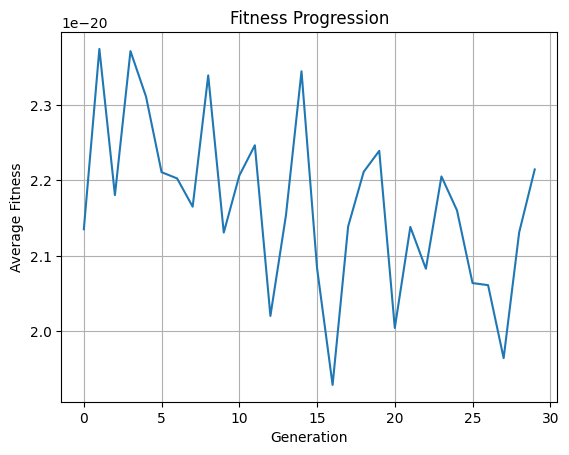

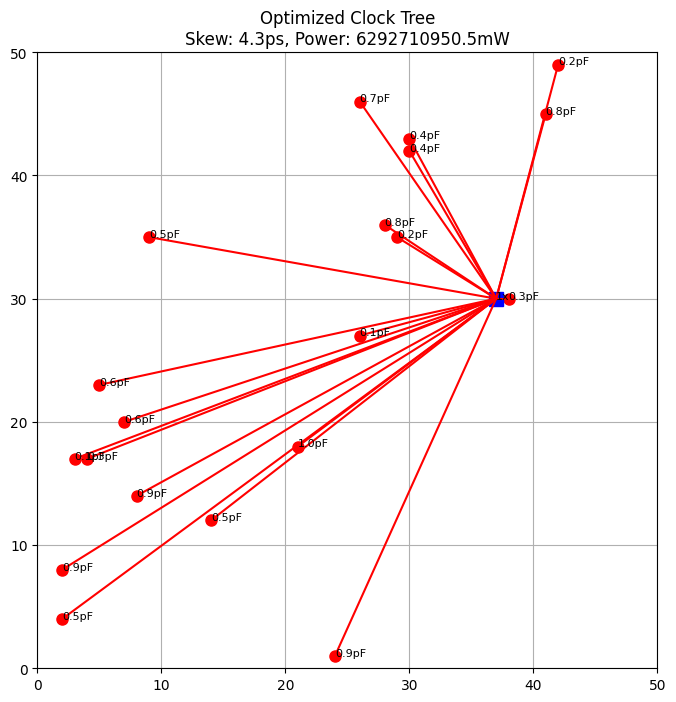

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque


NUM_SINKS = 20
GRID_SIZE = 50
MAX_BUFFERS = 30
SKEW_THRESHOLD = 100
POWER_THRESHOLD = 15

class ClockSink:
    def __init__(self, x, y, capacitance):
        self.x = x
        self.y = y
        self.capacitance = capacitance
        self.delay = 0
        self.path = []

    def __str__(self):
        return f"Sink@{self.x},{self.y} (cap:{self.capacitance:.1f}pF)"

class Buffer:
    def __init__(self, x, y, drive_strength):
        self.x = x
        self.y = y
        self.drive_strength = drive_strength
        self.input_cap = 0.1 * drive_strength
        self.delay = 10 / drive_strength
        self.fanout = []

    def add_fanout(self, node):
        self.fanout.append(node)

    def __str__(self):
        return f"Buffer@{self.x},{self.y} (str:{self.drive_strength}x)"

class ClockTree:
    def __init__(self):
        self.sinks = []
        self.buffers = []
        self.root = None
        self.skew = 0
        self.total_power = 0
        self.wirelength = 0

    def add_sink(self, sink):
        self.sinks.append(sink)

    def add_buffer(self, buffer):
        self.buffers.append(buffer)

    def calculate_skew(self):
        delays = [sink.delay for sink in self.sinks]
        self.skew = max(delays) - min(delays)
        return self.skew

    def calculate_power(self):
        self.total_power = 0
        for sink in self.sinks:
            self.total_power += 0.5 * sink.capacitance * (1.0 ** 2) * 1e9
        for buffer in self.buffers:
            self.total_power += 0.5 * buffer.input_cap * (1.0 ** 2) * 1e9 * len(buffer.fanout)
        return self.total_power * 1e3

    def calculate_wirelength(self):
        self.wirelength = 0
        for sink in self.sinks:
            if sink.path:
                last_node = sink.path[-1]
                self.wirelength += np.sqrt((sink.x - last_node.x)**2 + (sink.y - last_node.y)**2)
        for buffer in self.buffers:
            for fanout in buffer.fanout:
                if isinstance(fanout, Buffer):
                    self.wirelength += np.sqrt((buffer.x - fanout.x)**2 + (buffer.y - fanout.y)**2)
        return self.wirelength

    def evaluate(self):
        self.calculate_skew()
        self.calculate_power()
        self.calculate_wirelength()

        skew_penalty = max(0, self.skew - SKEW_THRESHOLD) ** 2
        power_penalty = max(0, self.total_power - POWER_THRESHOLD) ** 2

        fitness = 1 / (1 + skew_penalty + power_penalty + self.wirelength/100)
        return fitness

    def __str__(self):
        return f"Tree: {len(self.sinks)} sinks, {len(self.buffers)} buffers | Skew: {self.skew:.1f}ps, Power: {self.total_power:.1f}mW, WL: {self.wirelength:.1f}μm"

class GeneticOptimizer:
    def __init__(self, population_size=20):
        self.population_size = population_size
        self.population = []
        self.best_solution = None
        self.fitness_history = []

    def initialize_population(self, sinks):
        for _ in range(self.population_size):
            tree = self.generate_random_tree(sinks)
            self.population.append(tree)

    def generate_random_tree(self, sinks):
        tree = ClockTree()
        for sink in sinks:
            tree.add_sink(sink)


        num_buffers = random.randint(1, 5)
        buffers = []
        for _ in range(num_buffers):
            x = random.randint(0, GRID_SIZE)
            y = random.randint(0, GRID_SIZE)
            strength = random.choice([1, 2, 4])
            buffer = Buffer(x, y, strength)
            tree.add_buffer(buffer)
            buffers.append(buffer)


        for sink in tree.sinks:
            if buffers:
                nearest = min(buffers, key=lambda b: np.sqrt((sink.x-b.x)**2 + (sink.y-b.y)**2))
                nearest.add_fanout(sink)
                sink.path.append(nearest)


        if len(buffers) > 1:
            tree.root = buffers[0]
            for i in range(1, len(buffers)):
                parent = random.choice(buffers[:i])
                parent.add_fanout(buffers[i])

        self.calculate_delays(tree)
        tree.evaluate()
        return tree

    def calculate_delays(self, tree):
        if not tree.buffers:
            return

        if not tree.root:
            tree.root = tree.buffers[0]

        queue = deque()
        tree.root.delay = 0
        queue.append(tree.root)

        while queue:
            current = queue.popleft()
            for fanout in current.fanout:
                if isinstance(fanout, Buffer):
                    fanout.delay = current.delay + current.delay
                    queue.append(fanout)
                else:
                    wire_delay = np.sqrt((fanout.x-current.x)**2 + (fanout.y-current.y)**2) * 0.1
                    fanout.delay = current.delay + current.delay + wire_delay

    def evolve(self, generations=30):
        for gen in range(generations):

            new_population = []
            for _ in range(self.population_size):
                contestants = random.sample(self.population, 3)
                winner = max(contestants, key=lambda t: t.evaluate())

                new_population.append(self.mutate(self.copy_tree(winner)))

            self.population = new_population


            current_best = max(self.population, key=lambda t: t.evaluate())
            if not self.best_solution or current_best.evaluate() > self.best_solution.evaluate():
                self.best_solution = current_best


            avg_fitness = sum(t.evaluate() for t in self.population) / len(self.population)
            self.fitness_history.append(avg_fitness)

            if gen % 5 == 0:
                print(f"Gen {gen}: Best fitness = {self.best_solution.evaluate():.3f}")

        return self.best_solution

    def mutate(self, tree):

        mutation_type = random.choice(["add_buffer", "move_buffer", "change_strength"])

        if mutation_type == "add_buffer" and len(tree.buffers) < MAX_BUFFERS:
            x = random.randint(0, GRID_SIZE)
            y = random.randint(0, GRID_SIZE)
            strength = random.choice([1, 2, 4])
            new_buffer = Buffer(x, y, strength)
            tree.add_buffer(new_buffer)


            if tree.buffers:
                parent = random.choice(tree.buffers[:-1])
                parent.add_fanout(new_buffer)


            for sink in random.sample(tree.sinks, min(3, len(tree.sinks))):
                nearest = min(tree.buffers, key=lambda b: np.sqrt((sink.x-b.x)**2 + (sink.y-b.y)**2))
                sink.path = [nearest]
                nearest.add_fanout(sink)

        elif mutation_type == "move_buffer" and tree.buffers:
            buffer = random.choice(tree.buffers)
            buffer.x = np.clip(buffer.x + random.randint(-5, 5), 0, GRID_SIZE)
            buffer.y = np.clip(buffer.y + random.randint(-5, 5), 0, GRID_SIZE)

        elif mutation_type == "change_strength" and tree.buffers:
            buffer = random.choice(tree.buffers)
            buffer.drive_strength = random.choice([1, 2, 4])
            buffer.input_cap = 0.1 * buffer.drive_strength
            buffer.delay = 10 / buffer.drive_strength

        self.calculate_delays(tree)
        tree.evaluate()
        return tree

    def copy_tree(self, original):
        """Create a deep copy of a clock tree"""
        new_tree = ClockTree()


        sink_map = {}
        for sink in original.sinks:
            new_sink = ClockSink(sink.x, sink.y, sink.capacitance)
            new_tree.add_sink(new_sink)
            sink_map[id(sink)] = new_sink


        buffer_map = {}
        for buffer in original.buffers:
            new_buffer = Buffer(buffer.x, buffer.y, buffer.drive_strength)
            new_tree.add_buffer(new_buffer)
            buffer_map[id(buffer)] = new_buffer
            if buffer == original.root:
                new_tree.root = new_buffer


        for i, buffer in enumerate(original.buffers):
            new_buffer = buffer_map[id(buffer)]
            for fanout in buffer.fanout:
                if isinstance(fanout, Buffer):
                    new_buffer.add_fanout(buffer_map[id(fanout)])
                else:
                    new_buffer.add_fanout(sink_map[id(fanout)])

                    if buffer in fanout.path:

                        fanout_index = fanout.path.index(buffer)
                        fanout.path[fanout_index] = new_buffer
                    else:

                        fanout.path = [new_buffer]




        new_tree.skew = original.skew
        new_tree.total_power = original.total_power
        new_tree.wirelength = original.wirelength
        return new_tree

def generate_random_sinks(num_sinks):
    return [ClockSink(random.randint(0, GRID_SIZE),
                     random.randint(0, GRID_SIZE),
                     random.uniform(0.1, 1.0))
            for _ in range(num_sinks)]

def visualize_tree(tree):
    plt.figure(figsize=(8, 8))


    for sink in tree.sinks:
        plt.plot(sink.x, sink.y, 'ro', markersize=8)
        plt.text(sink.x, sink.y, f'{sink.capacitance:.1f}pF', fontsize=8)


    for buffer in tree.buffers:
        plt.plot(buffer.x, buffer.y, 'bs', markersize=10)
        plt.text(buffer.x, buffer.y, f'{buffer.drive_strength}x', fontsize=8)

        for fanout in buffer.fanout:
            if isinstance(fanout, Buffer):
                plt.plot([buffer.x, fanout.x], [buffer.y, fanout.y], 'b-')
            else:
                plt.plot([buffer.x, fanout.x], [buffer.y, fanout.y], 'r-')

    plt.title(f'Optimized Clock Tree\nSkew: {tree.skew:.1f}ps, Power: {tree.total_power:.1f}mW')
    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.grid(True)
    plt.show()

def plot_fitness(history):
    plt.plot(history)
    plt.title('Fitness Progression')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.grid(True)
    plt.show()

def main():
    print("=== AI-Powered Clock Tree Synthesis (Mini Project) ===")


    sinks = generate_random_sinks(NUM_SINKS)
    print(f"\nGenerated {len(sinks)} clock sinks:")
    for sink in sinks[:3]:
        print(sink)
    if len(sinks) > 3:
        print("...")


    print("\nRunning genetic optimization...")
    optimizer = GeneticOptimizer()
    optimizer.initialize_population(sinks)
    best_tree = optimizer.evolve()


    print("\nOptimization complete!")
    print(f"Best solution found:\n{best_tree}")


    plot_fitness(optimizer.fitness_history)
    visualize_tree(best_tree)

if __name__ == "__main__":
    main()